# Clusters vs signature effects

In [1]:
import os,sys
import pandas as pd
import numpy as np
import scanpy as sc

from pert2state_model.Perturb2StateModel import Perturb2StateModel

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import pearsonr

sys.path.append('../3_DE_analysis/')
from DE_analysis_utils import *

mpl.rcParams['pdf.fonttype'] = 42  # Embed fonts as TrueType
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.dpi'] = 300  # or 150, 200, etc.
plt.rcParams['savefig.dpi'] = 600

# Increase all font sizes
plt.rcParams['font.size'] = 16  # Base font size
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 15

In [2]:
import yaml
with open('../../metadata/figure_palettes.yaml', 'r') as f:
    palettes = yaml.safe_load(f)

In [3]:
import gseapy as gp
from gseapy import Msigdb
from gseapy import barplot, dotplot

msig = Msigdb()
kegg_gene_sets = msig.get_gmt(category= 'c2.cp.kegg_legacy', dbver="2025.1.Hs")
reactome_gene_sets = msig.get_gmt(category= 'c2.cp.reactome', dbver="2025.1.Hs")
hallmark_gene_sets = msig.get_gmt(category= 'h.all', dbver="2025.1.Hs")


def parse_gene_sets(filename):
   gene_sets = {}
   with open(filename, 'r') as f:
       for line in f:
           terms = line.strip().split('\t')
           gene_sets[terms[0]] = terms[2:]
   return gene_sets

OAKPATH = '/mnt/oak/'
KEGG_sets = parse_gene_sets(f'{OAKPATH}/users/emma/data//KEGG_2019_Human.txt')
GO_sets = parse_gene_sets(f'{OAKPATH}/users/emma/data/GO_Biological_Process_2023.txt')

/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/gseapy/msigdb.py:29: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  d = pd.read_html(resp.text)[0]
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/gseapy/msigdb.py:95: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  d = pd.read_html(resp.text)[0]


Plotting utils

In [4]:
def plot_regulator_effects(adata_de, genes, regulators, y_target, sort_by='perturbation', figsize=(18, 6), condition='Rest', return_data=False):
    """Plot effects of regulators on target genes.
    
    Args:
        top_rows: List of target genes to plot
        gr: List of regulators to analyze
        wide_de_results: DataFrame with DE results
        wide_de_results_signif: DataFrame with significance values
        y_target: Series with aging effects
    """

    # Get DE results and pivot to wide format
    long_de_results = get_DE_results_long(adata_de, targets=regulators, genes=genes, gene_id_col='gene_name')
    long_de_results = long_de_results[long_de_results['culture_condition'] == condition].copy()
    wide_de_results = long_de_results.pivot(index='gene', columns='target_contrast_gene_name', values='zscore').T
    wide_de_results_signif = long_de_results.pivot(index='gene', columns='target_contrast_gene_name', values='adj_p_value').T

    pl_df = wide_de_results.loc[regulators, genes].reset_index().melt(id_vars='target_contrast_gene_name')
    signif = wide_de_results_signif.loc[regulators, genes] < 0.1
    # Calculate mean values per gene
    gene_means = pl_df.groupby('gene')['value'].mean()
    # Sort either by aging effect (y_target) or mean perturbation effect
    if sort_by == 'aging':
        gene_order = y_target.loc[genes].sort_values().index
    elif sort_by == 'perturbation':
        gene_order = wide_de_results.loc[regulators, genes].mean().sort_values().index
    else:
        gene_order = genes # Keep original order
    pl_df['aging_effect'] = y_target.loc[pl_df['gene']].values
    pl_df['target_contrast_gene_name'] = pl_df['target_contrast_gene_name'].astype(str)
    pl_df['significant'] = False
    for gene in regulators:
        for target in genes:
            pl_df.loc[(pl_df['target_contrast_gene_name'] == gene) & (pl_df['gene'] == target), 'significant'] = signif.loc[gene, target]

    plt.figure(figsize=figsize)
    plt.axvline(x=0, color='grey', linestyle=':', zorder=0)

    palette = {name: sns.color_palette('Pastel1')[i] 
              for i, name in enumerate(pl_df['target_contrast_gene_name'].unique())}

    # Create base stripplot with legend using ordered regulators
    ax = sns.stripplot(data=pl_df[~pl_df.significant], y='gene', x='value', 
                      hue='target_contrast_gene_name', dodge=False, palette=palette, legend=False,
                      order=gene_order, size=8, alpha=0.5)

    # Add points with black outline for significant values, no legend
    ax = sns.stripplot(data=pl_df[pl_df.significant], y='gene', x='value', 
                      hue='target_contrast_gene_name', dodge=False, 
                      edgecolor='black', linewidth=1, palette=palette, legend=True,
                      order=gene_order, size=8, alpha=0.7)

    # Add scatter points for aging effect
    sns.scatterplot(data=pl_df, y='gene', x='aging_effect', 
                    s=200, color='black', marker='*', label='Aging signature effect')

    # Adjust y-axis labels
    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)

    # Add axis labels
    plt.ylabel('Signature genes', fontsize=14)
    plt.xlabel('Perturb-seq effect size\n(DE z-score)', fontsize=14)

    # Add white point with black outline to legend to indicate significance
    plt.scatter([], [], c='white', edgecolor='black', linewidth=1, s=80, label='Significant effect (10% FDR)')

    # Move legend outside with larger font
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Target gene', fontsize=12, title_fontsize=14, frameon=False)
    
    if return_data:
        return(wide_de_results, wide_de_results_signif)

## Load perturb-seq signatures

In [5]:
datadir = '/mnt/oak/users/emma/data/GWT/CD4i_final/'
experiment_name = 'CD4i_final'
adata_de = sc.read_h5ad(datadir + f'/DE_results_all_confounders/{experiment_name}.merged_DE_results.h5ad')

adata_de.layers['zscore'] = adata_de.layers['log_fc'] / adata_de.layers['lfcSE']
adata_de.layers['zscore'][np.where(adata_de.layers['zscore'] > 100)] = 100
for cond in adata_de.obs.culture_condition.unique():
    affected_gs_cond = np.sum(adata_de[adata_de.obs['culture_condition'] == cond].layers['adj_p_value'] < 0.1, axis=0)
    adata_de.var[f'n_signif_effects_{cond}'] = affected_gs_cond

adata_de.var_names = adata_de.var['gene_name'].values
adata_de.var_names

# Filter very lowly expressed genes
base_mean_df = sc.get.obs_df(adata_de, adata_de.var_names.tolist() + ['culture_condition', 'chunk'], layer='baseMean')
base_mean_df = base_mean_df.drop_duplicates().sort_values('culture_condition')

# Calculate for Rest condition
base_mean_rest = base_mean_df[base_mean_df['culture_condition'] == 'Rest'].set_index('chunk').drop('culture_condition', axis=1).T
adata_de.var['mean_baseMean_Rest'] = base_mean_rest.mean(1).fillna(0)
adata_de.var['std_baseMean_Rest'] = base_mean_rest.std(1).fillna(10000)

# Calculate for Stim8hr condition
base_mean_stim8 = base_mean_df[base_mean_df['culture_condition'] == 'Stim8hr'].set_index('chunk').drop('culture_condition', axis=1).T
adata_de.var['mean_baseMean_Stim8hr'] = base_mean_stim8.mean(1).fillna(0)
adata_de.var['std_baseMean_Stim8hr'] = base_mean_stim8.std(1).fillna(10000)

# Calculate for Stim48hr condition
base_mean_stim48 = base_mean_df[base_mean_df['culture_condition'] == 'Stim48hr'].set_index('chunk').drop('culture_condition', axis=1).T
adata_de.var['mean_baseMean_Stim48hr'] = base_mean_stim48.mean(1).fillna(0)
adata_de.var['std_baseMean_Stim48hr'] = base_mean_stim48.std(1).fillna(10000)

# Exclude from analysis genes with very low base mean (messing up reliability estimate)
gs_mask = (adata_de.var['mean_baseMean_Rest'] > 0.1) & (adata_de.var['mean_baseMean_Stim8hr'] > 0.1) & (adata_de.var['mean_baseMean_Stim48hr'] > 0.1)
adata_de = adata_de[:, gs_mask].copy()
sum(~gs_mask)

3677

In [6]:
# Load summary stats
DE_stats = pd.read_csv(datadir + f'/DE_results_all_confounders/DE_summary_stats_per_target.csv', index_col=0)


### Load cluster annotations

In [7]:
# Load cluster annotations
cluster_annot = pd.read_csv('../../metadata/suppl_tables/clustering_results_and_annotations.csv')
cluster_annot

,cluster,manual_annotation,intracluster_corr,cluster_size,cluster_gene_size,cluster_member,rest_count,stim8hr_count,stim48hr_count,cluster_member_with_condition,...,raw_p_value_reactome,complex_size_reactome,overlap_size_reactome,cluster_size_reactome,fdr_reactome,corr_rest,corr_stim8hr,corr_stim48hr,corr_shared,condition_specificity
0,0,Integrator complex,0.398472,20,7,"['SLC24A1', 'INTS13', 'INTS15', 'FGFR1OP2', 'I...",6,7,7,"['SLC24A1_Stim8hr', 'SLC24A1_Rest', 'INTS13_St...",...,2.454568e-03,81,3,7,1.000000,0.406482,0.512976,0.496743,0.356076,across_condition
1,1,RFX1/FOXN2 complex,0.333652,6,2,"['RFX1', 'FOXN2']",2,2,2,"['RFX1_Stim8hr', 'FOXN2_Stim48hr', 'RFX1_Stim4...",...,1.000000e+00,7,0,2,1.000000,0.382711,0.411564,0.292067,0.327721,across_condition
2,2,Ino80 complex,0.243528,29,11,"['INO80B', 'ACTR5', 'INO80', 'RO60', 'HEY1', '...",9,10,10,"['INO80B_Stim8hr', 'ACTR5_Rest', 'INO80_Rest',...",...,2.600000e-10,38,7,11,0.000006,0.261680,0.304254,0.281659,0.207156,across_condition
3,3,"STAG2-PAXIP1/PAGR1, genome stability",0.317834,9,3,"['PAGR1', 'STAG2', 'PAXIP1']",3,3,3,"['PAGR1_Stim48hr', 'PAGR1_Rest', 'PAGR1_Stim8h...",...,1.472596e-03,42,2,3,1.000000,0.508555,0.503570,0.453038,0.296780,across_condition
4,4,unknown,0.371634,6,2,"['BRMS1', 'SAP130']",2,2,2,"['BRMS1_Stim48hr', 'BRMS1_Rest', 'BRMS1_Stim8h...",...,1.000000e+00,7,0,2,1.000000,0.494691,0.518754,0.535180,0.376514,across_condition
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,107,unknown,0.313915,9,9,"['THAP12', 'HSD17B12', 'DTWD1', 'MLYCD', 'CTSO...",0,0,9,"['THAP12_Stim48hr', 'HSD17B12_Stim48hr', 'DTWD...",...,2.047122e-01,175,2,9,1.000000,0.074705,0.070581,0.353155,0.100313,Stim48hr
108,108,mTORC signaling,0.291124,4,4,"['PDPK1', 'RICTOR', 'MAPKAP1', 'MLST8']",0,0,4,"['PDPK1_Stim48hr', 'RICTOR_Stim48hr', 'MAPKAP1...",...,3.010000e-08,26,4,4,0.000238,0.343638,0.241079,0.388166,0.158522,across_condition
109,109,unknown,0.271799,15,15,"['EDC3', 'NGLY1', 'BRK1', 'COL6A1', 'NCKAP1L',...",0,0,15,"['EDC3_Stim48hr', 'NGLY1_Stim48hr', 'BRK1_Stim...",...,3.080920e-02,88,3,15,1.000000,0.039248,0.053212,0.291213,0.052854,Stim48hr
110,110,unknown,0.201673,5,5,"['PARP2', 'ZBTB14', 'FBXO42', 'SH3GL1', 'COA6']",0,0,5,"['PARP2_Stim48hr', 'ZBTB14_Stim48hr', 'FBXO42_...",...,1.000000e+00,7,0,5,1.000000,0.057377,0.055012,0.252092,0.057645,Stim48hr


In [8]:
# Load polarization prediction coefficients (ota signature, Stim8hr condition)
polarity_coef = pd.read_csv('../../metadata/suppl_tables/polarization_prediction_condition_comparison_regulator_coefficients.csv', index_col=0)
polarity_stim8 = polarity_coef[polarity_coef['dataset_key'] == 'ota_Stim8hr'].copy()
polarity_stim8.index = polarity_stim8['regulator'] + '_Stim8hr'
polarity_stim8.head()

,coef_mean,coef_sem,coef_rank,regulator,known_regulators,dataset_key,regulator_type,celltype,signature
regulator,,,,,,,,,
UBR7_Stim8hr,0.004339,0.001078,0.342588,UBR7,False,ota_Stim8hr,NaN,Stim8hr,ota
PYGL_Stim8hr,-0.006004,0.001004,0.762863,PYGL,False,ota_Stim8hr,NaN,Stim8hr,ota
CENPT_Stim8hr,0.011623,0.000486,0.118696,CENPT,False,ota_Stim8hr,NaN,Stim8hr,ota
PLAT_Stim8hr,0.011851,0.000674,0.116403,PLAT,False,ota_Stim8hr,NaN,Stim8hr,ota
HSPA8_Stim8hr,-0.010143,0.000940,0.869587,HSPA8,False,ota_Stim8hr,NaN,Stim8hr,ota


/tmp/ipykernel_3565449/2428518667.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_main.set_yticklabels(ax_main.get_yticklabels(), fontsize=12)


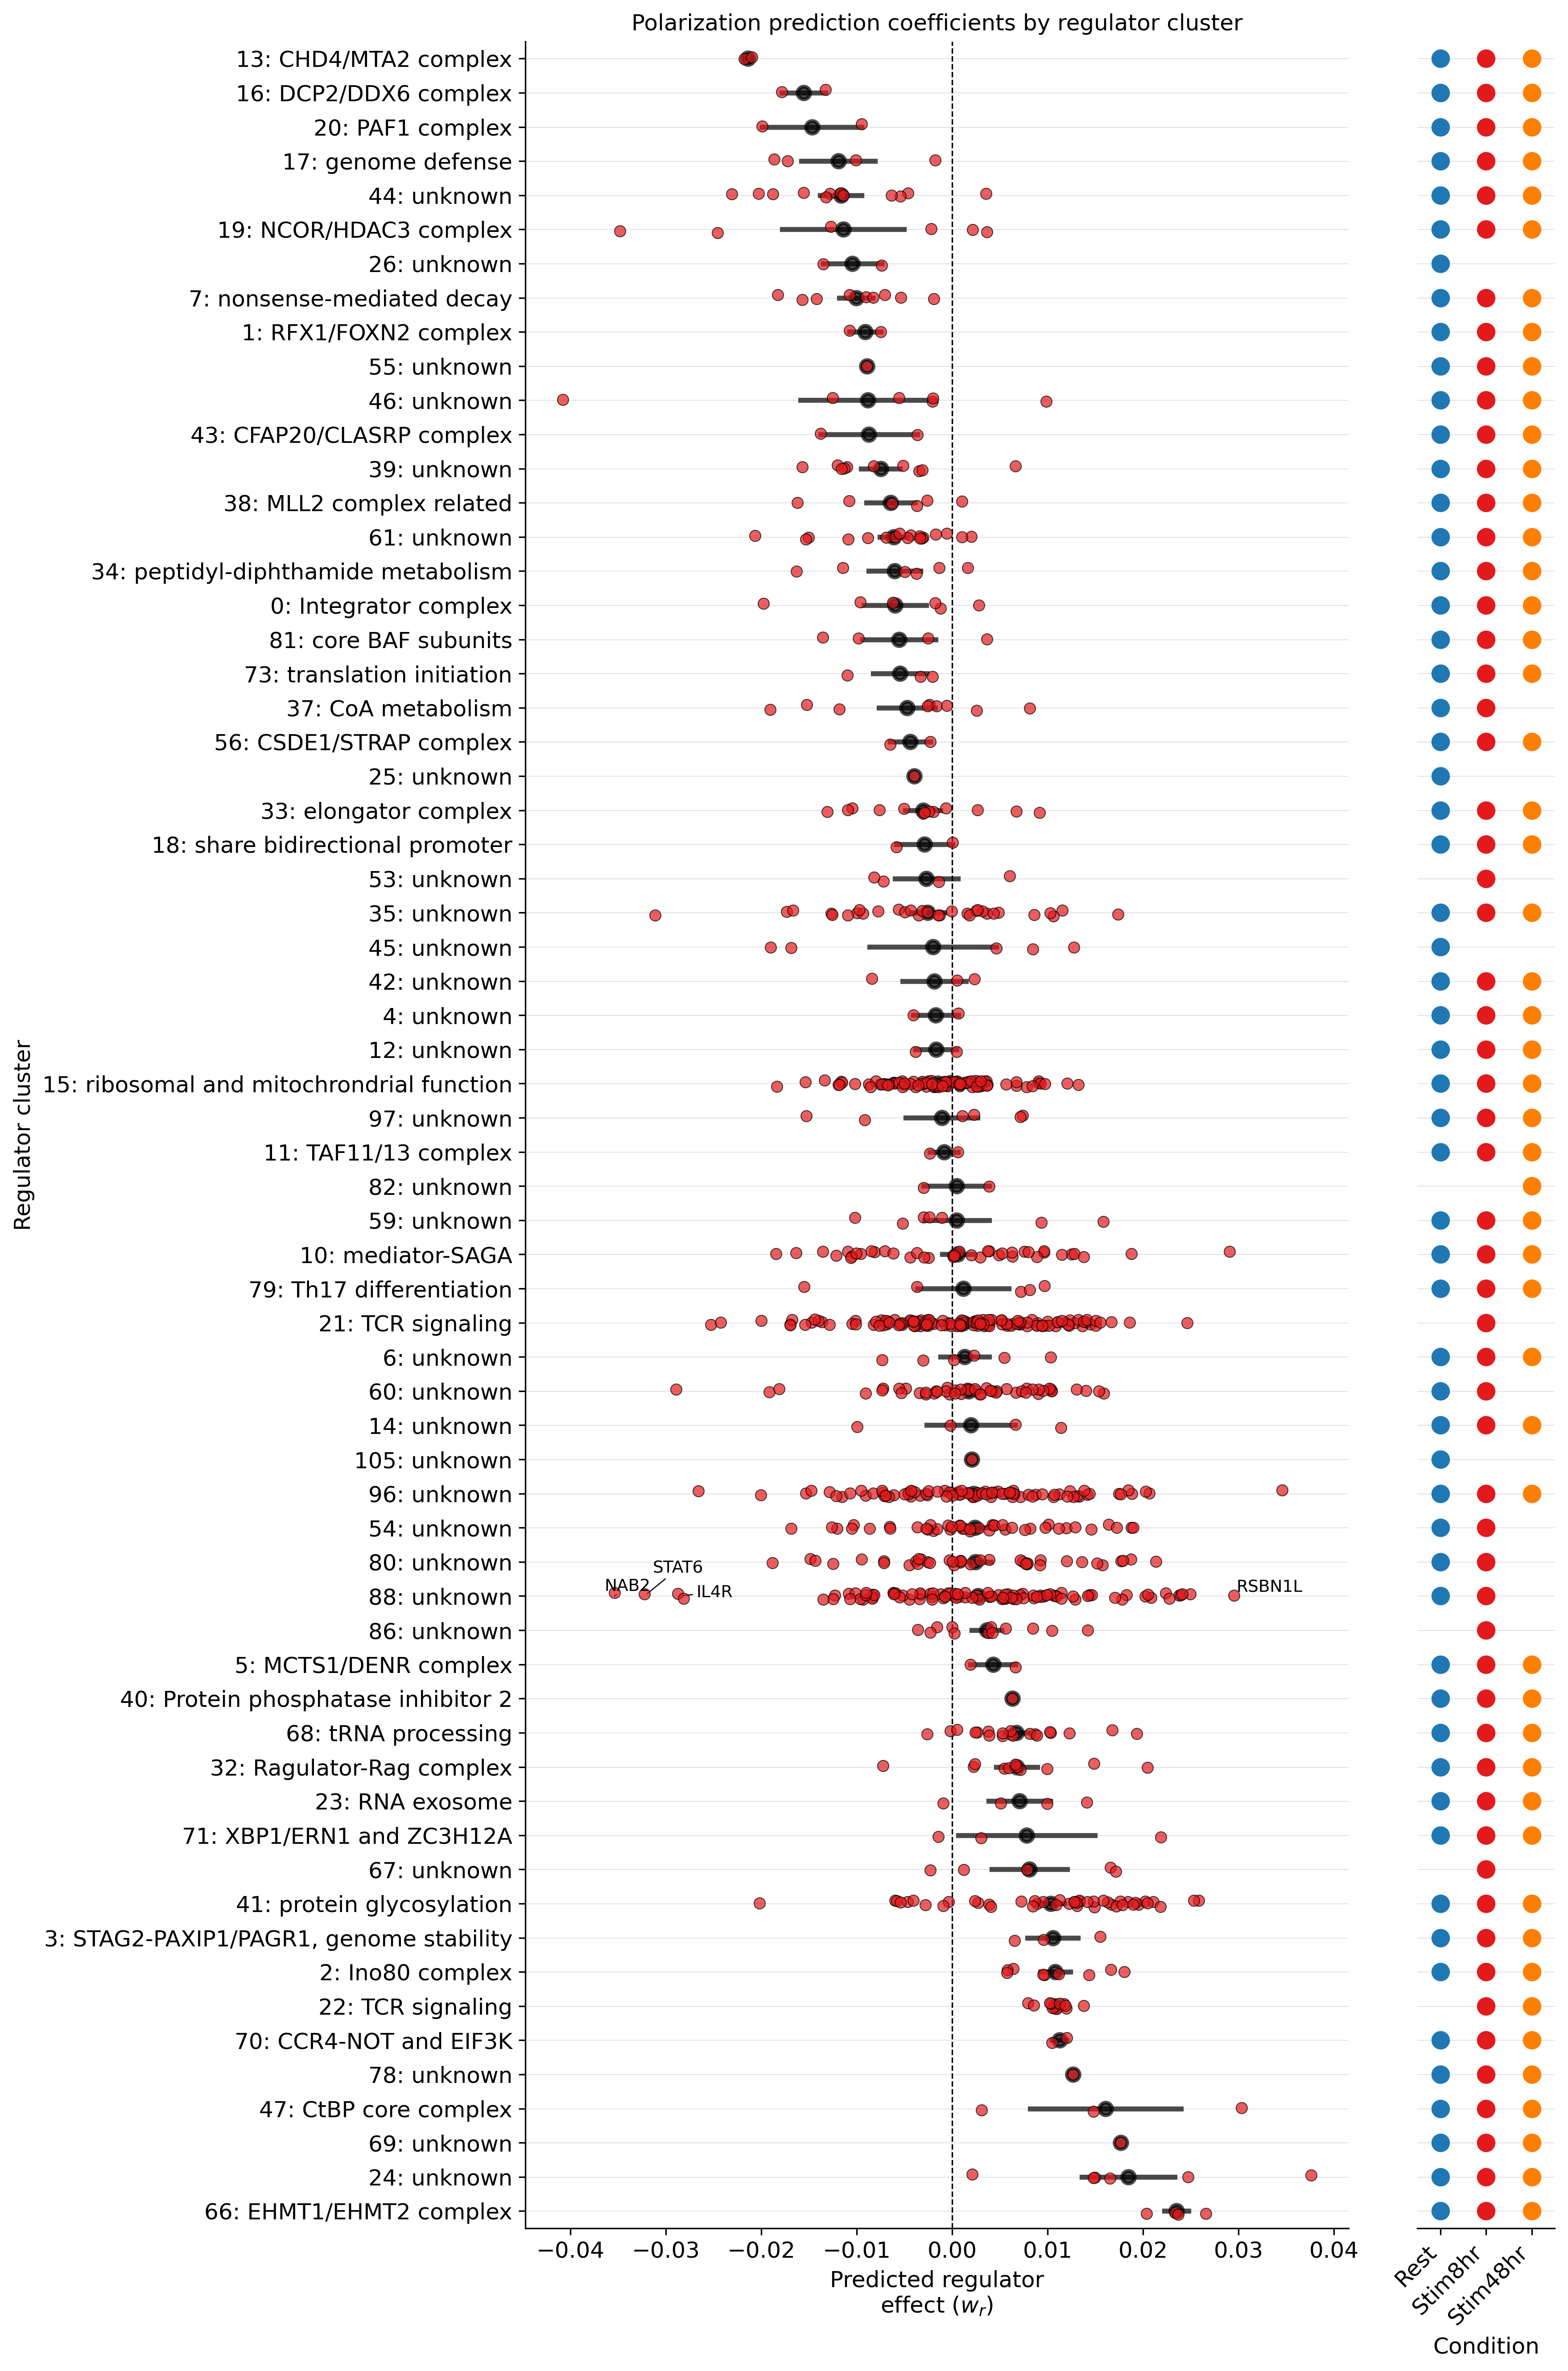

In [16]:
# Plot ota_Stim8hr polarization coefficients per cluster (Stim8hr members only)
import ast
from adjustText import adjust_text

# Build per-cluster data: only Stim8hr members with available coefficients
cluster_plot_data = []
for _, row in cluster_annot.iterrows():
    members = ast.literal_eval(row['cluster_member_with_condition'])
    stim8_members = [m for m in members if m.endswith('_Stim8hr')]
    if not stim8_members:
        continue
    available = [m for m in stim8_members if m in polarity_stim8.index]
    if not available:
        continue
    df = polarity_stim8.loc[available, ['coef_mean', 'coef_sem']].copy()
    df['member'] = df.index.str.replace('_Stim8hr', '', regex=False)
    df['cluster'] = row['cluster']
    df['annotation'] = row['manual_annotation']
    cluster_plot_data.append(df)

plot_df = pd.concat(cluster_plot_data).reset_index(drop=True)
plot_df['cluster_label'] = plot_df['cluster'].astype(str) + ': ' + plot_df['annotation']

# Add condition_specificity from cluster_annot
cs_map = cluster_annot.set_index('cluster')['condition_specificity']
plot_df['condition_specificity'] = plot_df['cluster'].map(cs_map)

# Sort clusters by mean coef_mean
cluster_order = (plot_df.groupby('cluster_label')['coef_mean']
                 .mean()
                 .sort_values()
                 .index.tolist())

# Build side panel: map condition_specificity -> list of active conditions
conditions_all = ['Rest', 'Stim8hr', 'Stim48hr']

def get_conditions(spec):
    if spec == 'across_condition':
        return ['Rest', 'Stim8hr', 'Stim48hr']
    elif spec == 'Rest_Stim8hr':
        return ['Rest', 'Stim8hr']
    elif spec == 'Stim8hr_Stim48hr':
        return ['Stim8hr', 'Stim48hr']
    else:
        return [spec]

cond_x = {c: i for i, c in enumerate(conditions_all)}
y_pos = {label: i for i, label in enumerate(cluster_order)}

side_rows = []
for cl_label in cluster_order:
    cs = plot_df.loc[plot_df['cluster_label'] == cl_label, 'condition_specificity'].iloc[0]
    for cond in get_conditions(cs):
        side_rows.append({'cluster_label': cl_label, 'condition': cond,
                          'y': y_pos[cl_label], 'x': cond_x[cond]})
side_df = pd.DataFrame(side_rows)

n_clusters = len(cluster_order)
fig, (ax_main, ax_side) = plt.subplots(
    1, 2, figsize=(12, n_clusters * 0.25 + 2),
    gridspec_kw={'width_ratios': [6, 1]}, sharey=True
)
fig.subplots_adjust(wspace=0.02)

# Main plot (horizontal: y=cluster, x=coefficient)
sns.pointplot(data=plot_df, y='cluster_label', x='coef_mean', order=cluster_order,
              color='black', errorbar='se', linestyles='', markers='o', dodge=False,
              alpha=0.7, ax=ax_main)
sns.stripplot(data=plot_df, y='cluster_label', x='coef_mean', order=cluster_order,
              color=palettes['culture_condition']['Stim8hr'], size=6, alpha=0.7, jitter=True,
              edgecolor='black', linewidth=0.5, ax=ax_main)

ax_main.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax_main.grid(axis='y', linewidth=0.3, color='lightgrey', zorder=0)
ax_main.set_axisbelow(True)
ax_main.set_yticklabels(ax_main.get_yticklabels(), fontsize=12)
ax_main.tick_params(axis='x', labelsize=12)
ax_main.set_xlabel('Predicted regulator\neffect ($w_r$)', fontsize=12)
ax_main.set_ylabel('Regulator cluster', fontsize=12)
ax_main.set_title('Polarization prediction coefficients by regulator cluster', fontsize=12)
sns.despine(ax=ax_main)

# Reduce whitespace at top and bottom of y-axis
ax_main.set_ylim(n_clusters - 0.5, -0.5)

# Annotate top 3 and bottom 1 regulators in cluster 88
cl88_label = [l for l in cluster_order if l.startswith('88:')][0]
cl88_df = plot_df[plot_df['cluster_label'] == cl88_label].sort_values('coef_mean')
to_annotate = pd.concat([cl88_df.iloc[:3], cl88_df.iloc[-1:]])  # bottom 1, top 3
cl88_y = y_pos[cl88_label]

texts = []
for _, r in to_annotate.iterrows():
    texts.append(ax_main.text(r['coef_mean'], cl88_y, r['member'], fontsize=9))

adjust_text(texts, ax=ax_main,
            arrowprops=dict(arrowstyle='-', color='black', lw=0.6))

# Side condition panel
for cond in conditions_all:
    cond_df = side_df[side_df['condition'] == cond]
    ax_side.scatter(cond_df['x'], cond_df['y'],
                    color=palettes['culture_condition'][cond],
                    s=80, zorder=3)

ax_side.set_xlim(-0.5, 2.5)
ax_side.set_xticks([0, 1, 2])
ax_side.set_xticklabels(conditions_all, rotation=45, fontsize=12, ha='right')
ax_side.set_xlabel('Condition', fontsize=12)
ax_side.tick_params(axis='y', left=False, labelleft=False)
ax_side.grid(axis='y', linewidth=0.3, color='lightgrey', zorder=0)
ax_side.set_axisbelow(True)
sns.despine(ax=ax_side, left=True)

plt.savefig('./results/cluster_ota_stim8hr_coefficients.pdf', bbox_inches='tight')
plt.show()

Notes:
- EHMT1/2 are known to do histone methylation at cytokine and chemokine loci

In [10]:
plot_df[plot_df['cluster'] == 88].sort_values('coef_mean')

,coef_mean,coef_sem,member,cluster,annotation,cluster_label,condition_specificity
833,-0.035403,0.000737,NAB2,88,unknown,88: unknown,Rest_Stim8hr
829,-0.032269,0.001103,STAT6,88,unknown,88: unknown,Rest_Stim8hr
770,-0.028751,0.001119,IL4R,88,unknown,88: unknown,Rest_Stim8hr
798,-0.028153,0.000942,PTPN2,88,unknown,88: unknown,Rest_Stim8hr
791,-0.013510,0.000588,TNPO1,88,unknown,88: unknown,Rest_Stim8hr
...,...,...,...,...,...,...,...
738,0.023789,0.000575,ZNF781,88,unknown,88: unknown,Rest_Stim8hr
759,0.023973,0.000865,EIF3L,88,unknown,88: unknown,Rest_Stim8hr
810,0.024087,0.000650,BMI1,88,unknown,88: unknown,Rest_Stim8hr
771,0.024923,0.001114,PSMF1,88,unknown,88: unknown,Rest_Stim8hr


/tmp/ipykernel_3565449/4164819756.py:93: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_bottom.set_xticklabels(cluster_order_aging, rotation=45, fontsize=12, ha='right')


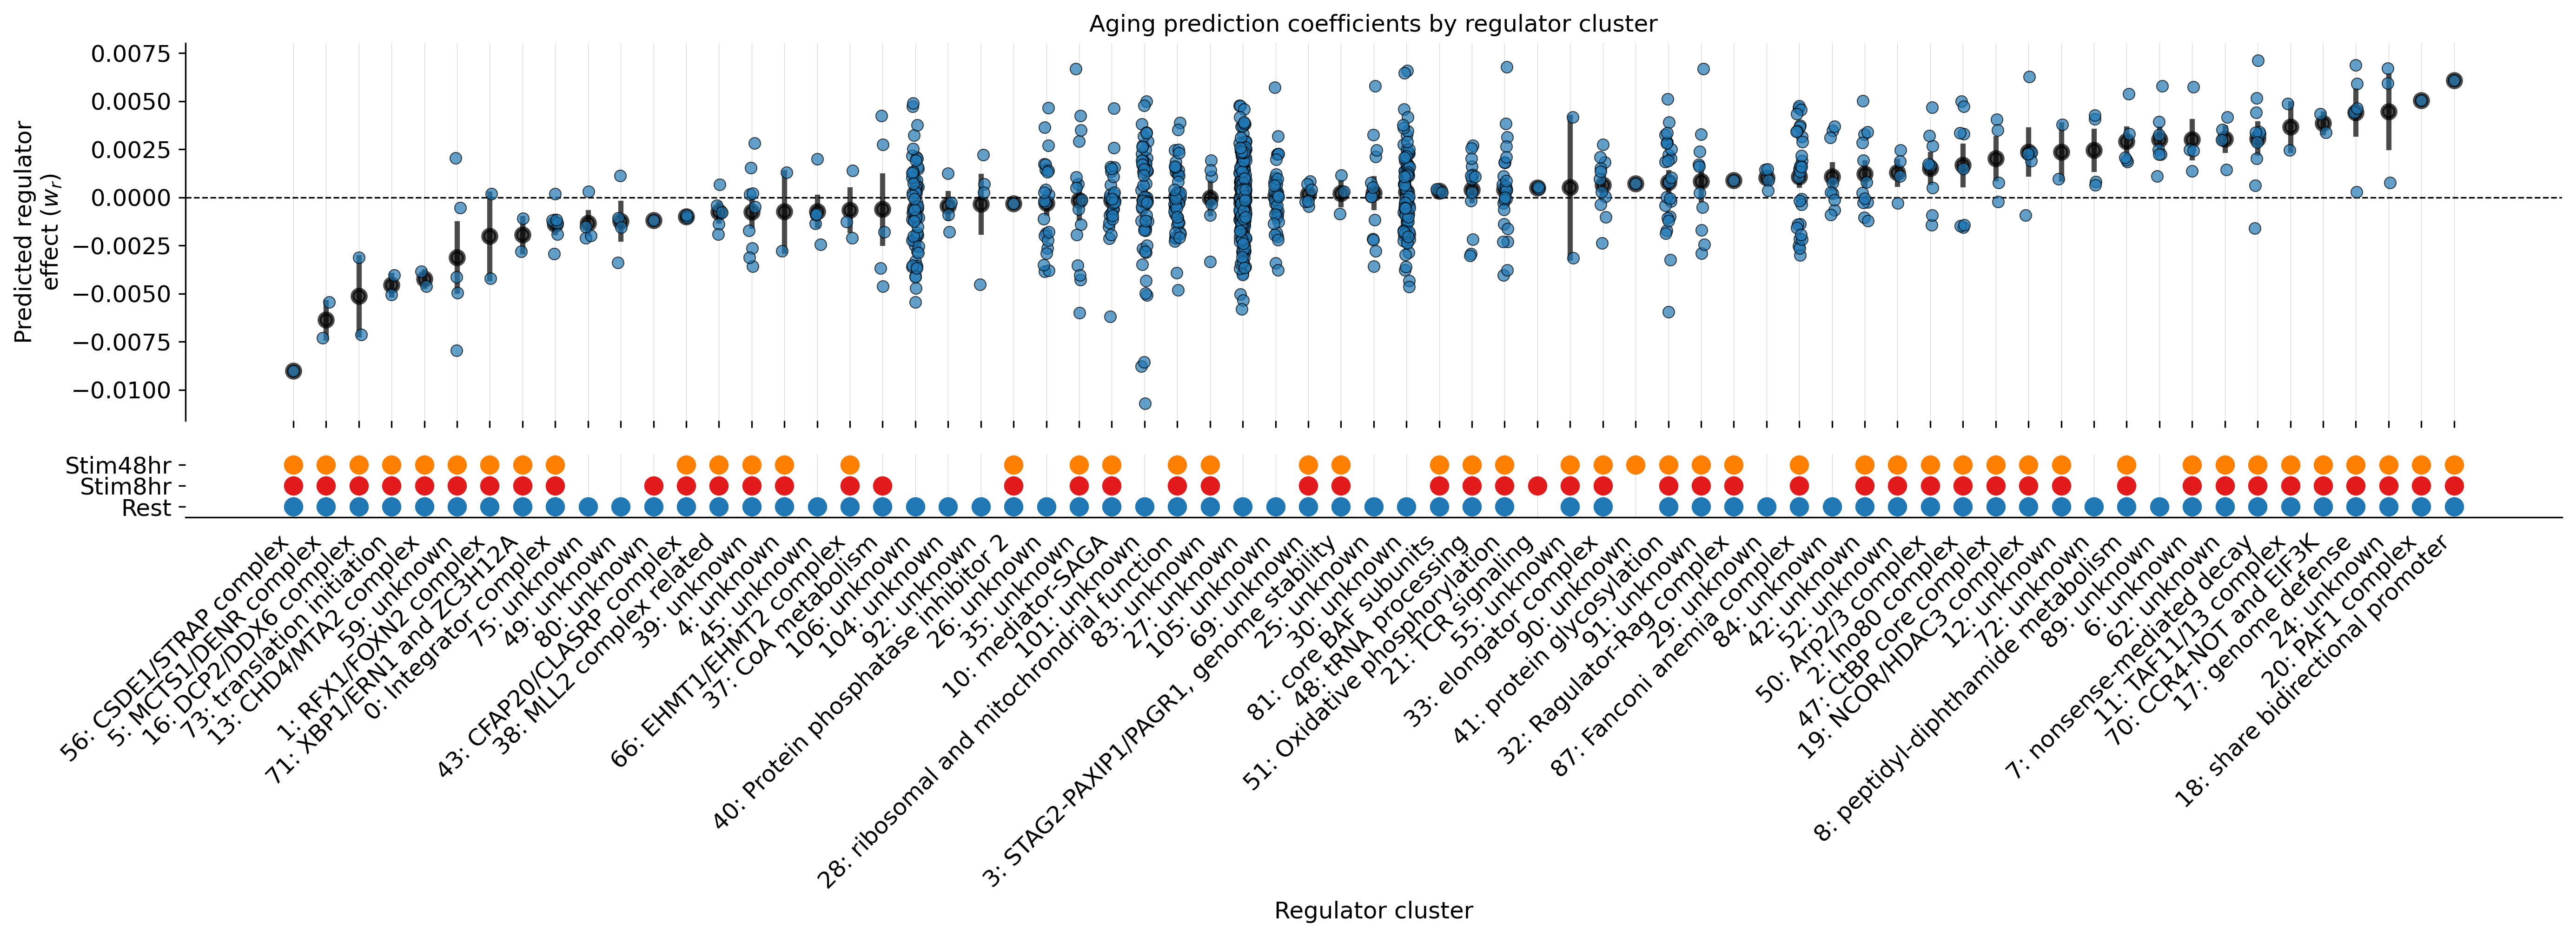

In [13]:
# Load aging prediction coefficients (CD4T signature, Rest condition)
aging_coef = pd.read_csv('../../metadata/suppl_tables/aging_prediction_condition_comparison_regulator_coefficients.csv', index_col=0)
aging_rest = aging_coef[aging_coef['dataset_key'] == 'CD4T_Rest'].copy()
aging_rest.index = aging_rest['regulator'] + '_Rest'

# Build per-cluster data
aging_plot_data = []
for _, row in cluster_annot.iterrows():
    members = ast.literal_eval(row['cluster_member_with_condition'])
    rest_members = [m for m in members if m.endswith('_Rest')]
    if not rest_members:
        continue
    available = [m for m in rest_members if m in aging_rest.index]
    if not available:
        continue
    df = aging_rest.loc[available, ['coef_mean', 'coef_sem']].copy()
    df['member'] = df.index.str.replace('_Rest', '', regex=False)
    df['cluster'] = row['cluster']
    df['annotation'] = row['manual_annotation']
    aging_plot_data.append(df)

aging_plot_df = pd.concat(aging_plot_data).reset_index(drop=True)
aging_plot_df['cluster_label'] = aging_plot_df['cluster'].astype(str) + ': ' + aging_plot_df['annotation']

# Add condition_specificity from cluster_annot
cs_map = cluster_annot.set_index('cluster')['condition_specificity']
aging_plot_df['condition_specificity'] = aging_plot_df['cluster'].map(cs_map)

cluster_order_aging = (aging_plot_df.groupby('cluster_label')['coef_mean']
                       .mean()
                       .sort_values()
                       .index.tolist())

# Build bottom panel: map condition_specificity -> list of active conditions
conditions_all = ['Rest', 'Stim8hr', 'Stim48hr']

def get_conditions(spec):
    if spec == 'across_condition':
        return ['Rest', 'Stim8hr', 'Stim48hr']
    elif spec == 'Rest_Stim8hr':
        return ['Rest', 'Stim8hr']
    elif spec == 'Stim8hr_Stim48hr':
        return ['Stim8hr', 'Stim48hr']
    else:
        return [spec]

cond_y = {c: i for i, c in enumerate(conditions_all)}
x_pos_aging = {label: i for i, label in enumerate(cluster_order_aging)}

side_rows = []
for cl_label in cluster_order_aging:
    cs = aging_plot_df.loc[aging_plot_df['cluster_label'] == cl_label, 'condition_specificity'].iloc[0]
    for cond in get_conditions(cs):
        side_rows.append({'cluster_label': cl_label, 'condition': cond,
                          'x': x_pos_aging[cl_label], 'y': cond_y[cond]})
side_aging_df = pd.DataFrame(side_rows)

n_clusters = len(cluster_order_aging)
fig, (ax_main, ax_bottom) = plt.subplots(
    2, 1, figsize=(n_clusters * 0.25 + 2, 7),
    gridspec_kw={'height_ratios': [6, 1]}, sharex=True
)
fig.subplots_adjust(hspace=0.02)

# Main plot (vertical: x=cluster, y=coefficient)
sns.pointplot(data=aging_plot_df, x='cluster_label', y='coef_mean', order=cluster_order_aging,
              color='black', errorbar='se', linestyles='', markers='o', dodge=False,
              alpha=0.7, ax=ax_main)
sns.stripplot(data=aging_plot_df, x='cluster_label', y='coef_mean', order=cluster_order_aging,
              color=palettes['culture_condition']['Rest'], size=6, alpha=0.7, jitter=True,
              edgecolor='black', linewidth=0.5, ax=ax_main)

ax_main.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_main.grid(axis='x', linewidth=0.3, color='lightgrey', zorder=0)
ax_main.set_axisbelow(True)
ax_main.tick_params(axis='x', labelsize=12)
ax_main.tick_params(axis='y', labelsize=12)
ax_main.set_xlabel('')
ax_main.set_ylabel('Predicted regulator\neffect ($w_r$)', fontsize=12)
ax_main.set_title('Aging prediction coefficients by regulator cluster', fontsize=12)
sns.despine(ax=ax_main, bottom=True)

# Bottom condition panel
for cond in conditions_all:
    cond_df = side_aging_df[side_aging_df['condition'] == cond]
    ax_bottom.scatter(cond_df['x'], cond_df['y'],
                      color=palettes['culture_condition'][cond],
                      s=80, zorder=3)

ax_bottom.set_ylim(-0.5, 2.5)
ax_bottom.set_yticks([0, 1, 2])
ax_bottom.set_yticklabels(conditions_all, fontsize=12)
ax_bottom.set_xticklabels(cluster_order_aging, rotation=45, fontsize=12, ha='right')
ax_bottom.tick_params(axis='x', bottom=False)
ax_bottom.grid(axis='x', linewidth=0.3, color='lightgrey', zorder=0)
ax_bottom.set_axisbelow(True)
ax_bottom.set_xlabel('Regulator cluster', fontsize=12)
sns.despine(ax=ax_bottom, left=True)

plt.savefig('./results/cluster_aging_rest_coefficients.pdf', bbox_inches='tight')
plt.show()

In [12]:
aging_plot_df[aging_plot_df.cluster == 17].sort_values('coef_mean')

,coef_mean,coef_sem,member,cluster,annotation,cluster_label,condition_specificity
82,0.000272,0.000465,ATF7IP2,17,genome defense,17: genome defense,across_condition
78,0.004408,0.000253,ZNF274,17,genome defense,17: genome defense,across_condition
80,0.004640,0.000398,SETDB1,17,genome defense,17: genome defense,across_condition
79,0.005907,0.000257,UBR1,17,genome defense,17: genome defense,across_condition
81,0.006875,0.000229,UBE2I,17,genome defense,17: genome defense,across_condition


(<Figure size 2400x2400 with 1 Axes>,
 <Axes: title={'center': 'STAT6 knock-out effect\nPSMF1 vs STAT6 comparison'}, xlabel='DE effect (PSMF1)', ylabel='DE effect (STAT6)'>,
 target_contrast_gene_name     PSMF1     STAT6
 gene                                         
 AAAS                      -2.904997 -0.871238
 AACS                      -1.289444  0.271056
 AAGAB                     -0.229275 -0.007642
 AAK1                      -0.611603 -0.206069
 AAMDC                     -1.210013 -0.048949
 ...                             ...       ...
 ZYG11A                    -0.946354 -0.670013
 ZYG11B                    -1.004055  0.041654
 ZYX                       -1.930966 -0.752867
 ZZEF1                     -0.183916  0.053505
 ZZZ3                      -1.189655 -1.434639
 
 [10282 rows x 2 columns])

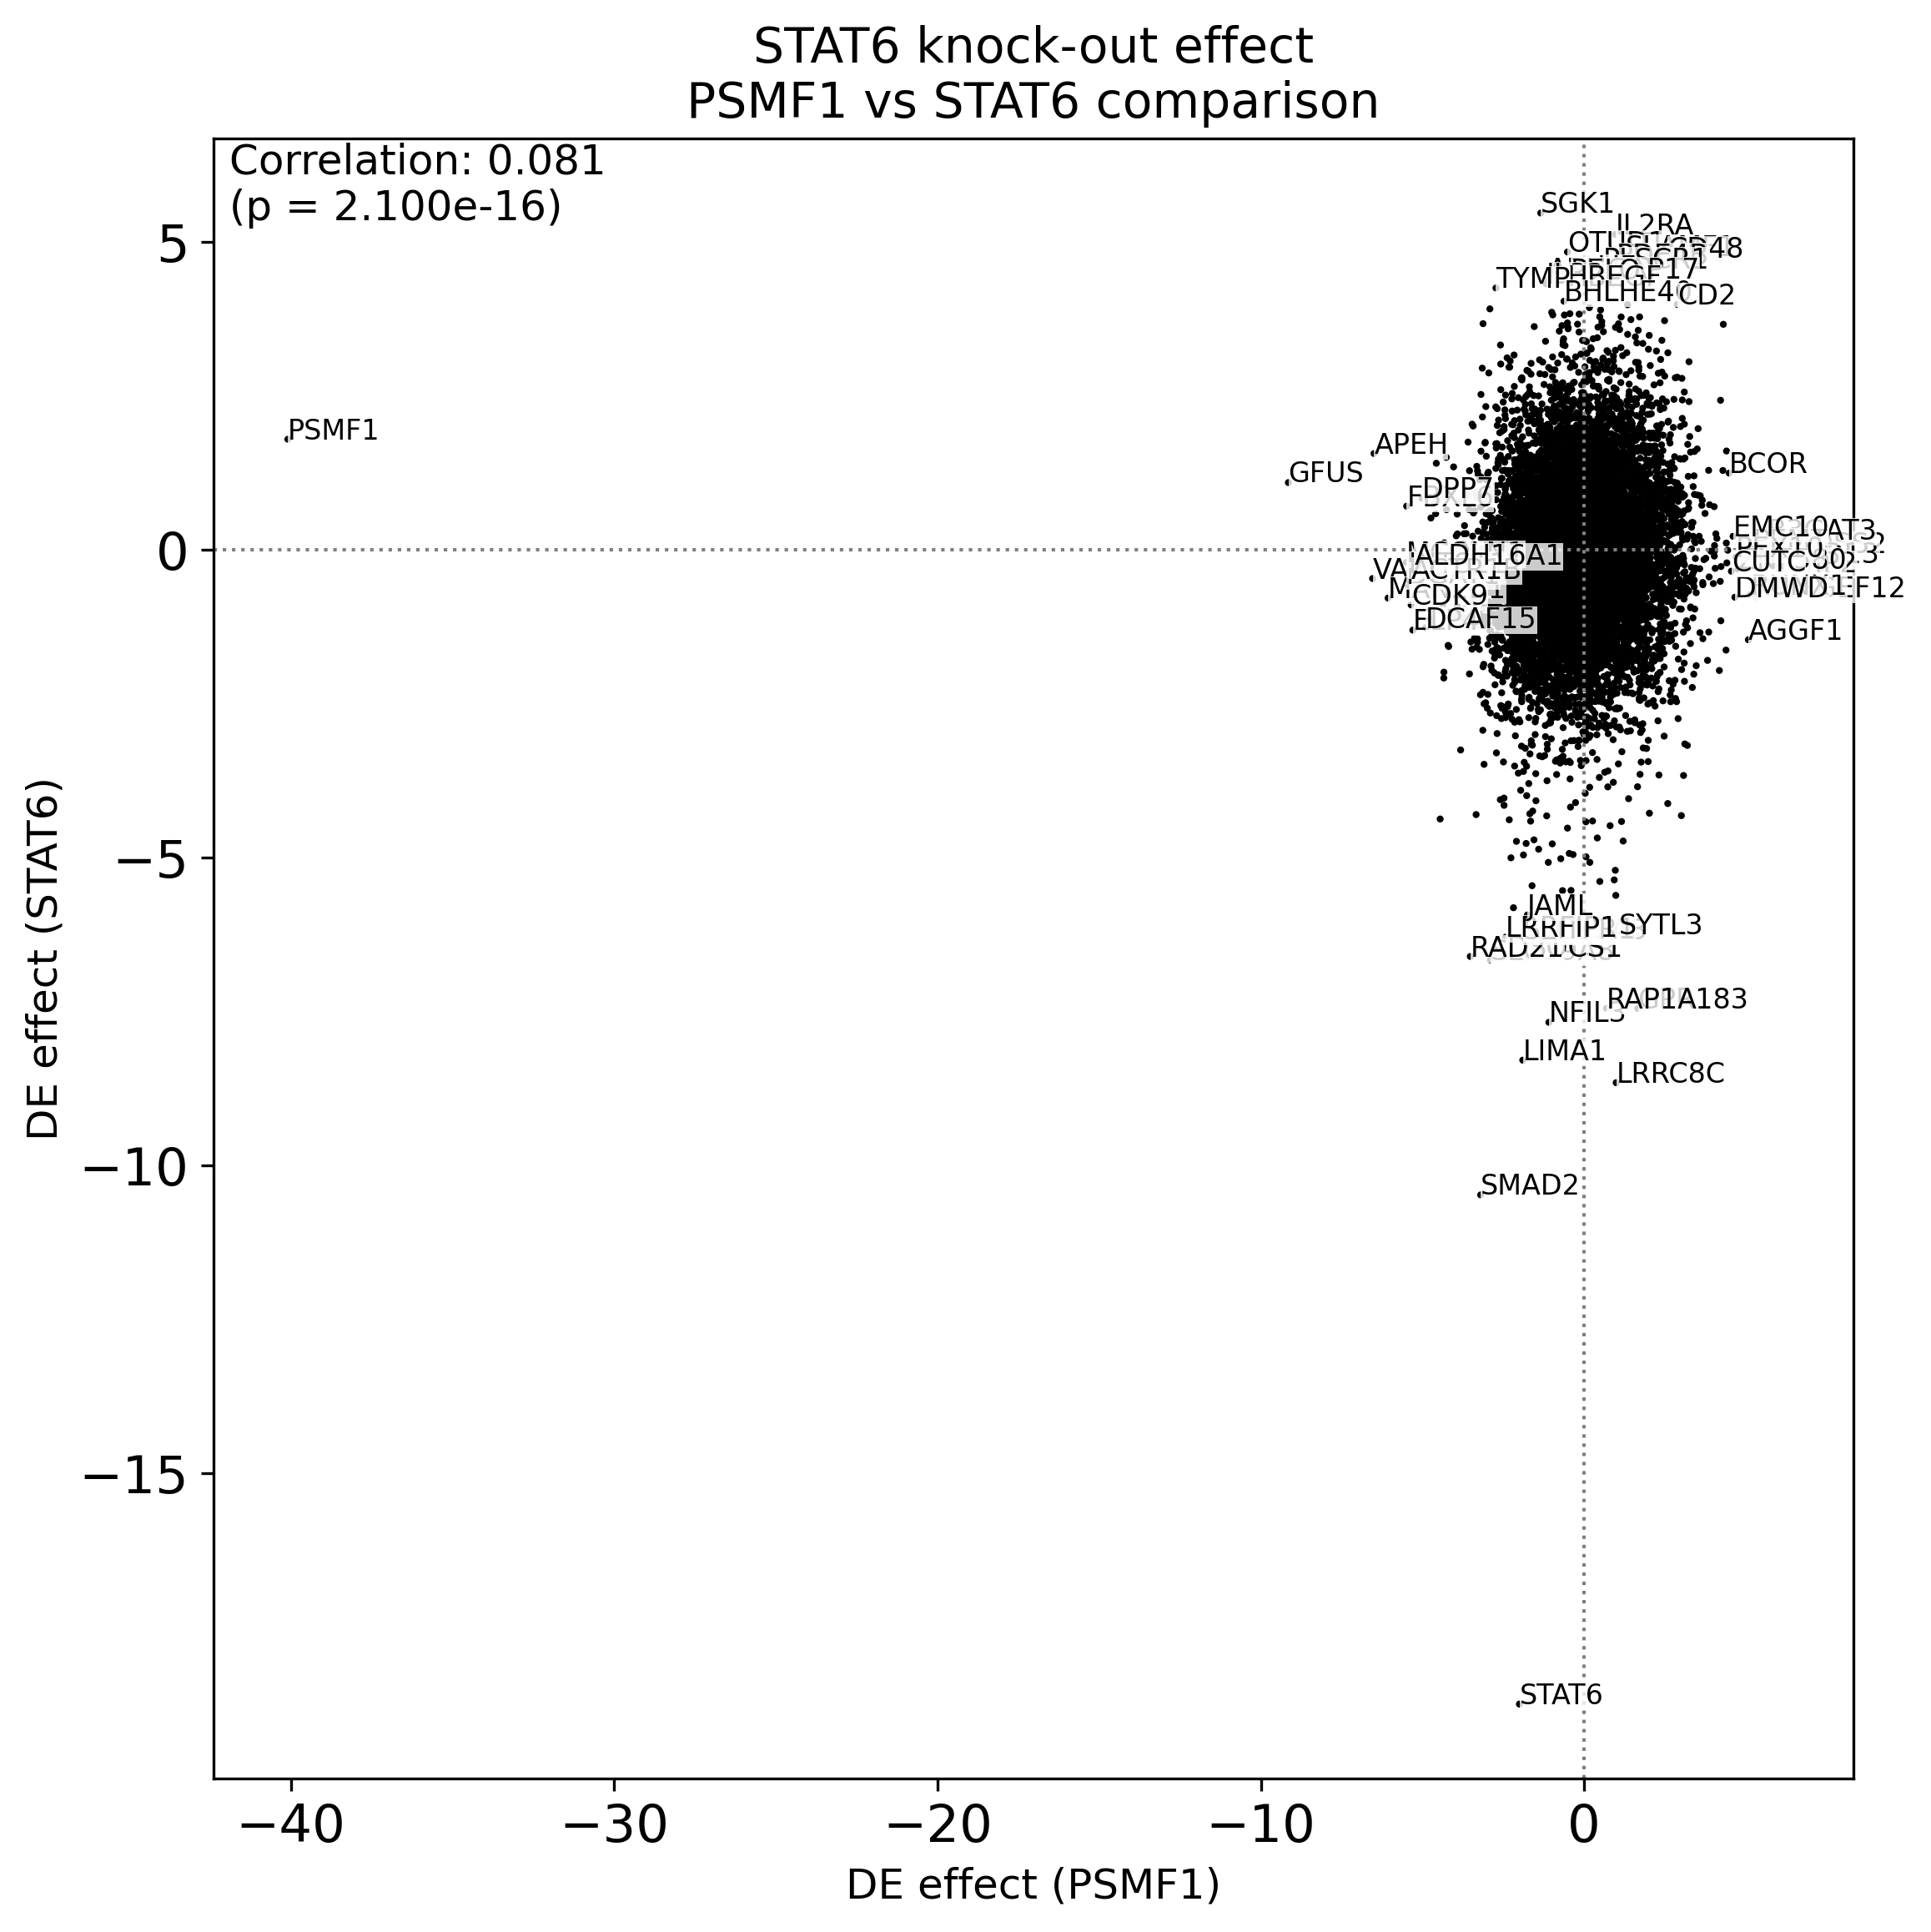

In [26]:
plot_effect_comparison(adata_de, 
    comparison_params = {
        'target_contrast_gene_name':['STAT6', 'PSMF1'],
        'culture_condition':['Stim8hr'],
        'stat':['zscore'],
    }, plot_correlation=True
)

In [25]:
cluster_annot[cluster_annot['cluster'] == 88].iloc[0]

cluster                                                                         88
manual_annotation                                                          unknown
intracluster_corr                                                         0.180414
cluster_size                                                                    99
cluster_gene_size                                                               99
cluster_member                   ['LMTK2', 'ZNF781', 'DUSP12', 'UNC45A', 'NAF1'...
rest_count                                                                       0
stim8hr_count                                                                   98
stim48hr_count                                                                   1
cluster_member_with_condition    ['LMTK2_Stim8hr', 'ZNF781_Stim8hr', 'DUSP12_St...
complex_corum                                            ATAC complex, GCN5-linked
overlap_genes_corum                                             ['MBIP', 'YEATS2']
over

### Mean cluster effects on cytokines

In [32]:
immune_genes_df = pd.read_csv('../../metadata/immune_effector_genes.csv')
cytokines = immune_genes_df[immune_genes_df['Category'] == 'Cytokine']['gene_name'].tolist()

exclude = ['IL17F', 'IL6'] 
cytokines = [x for x in cytokines if x not in exclude]
len(cytokines)

34

In [35]:
# Mean DE zscore effect of each cluster on cytokines
import ast

# Build a key in adata_de: gene_condition (matches cluster_member_with_condition)
de_obs = adata_de.obs.copy()
de_obs['member_key'] = de_obs['target_contrast_gene_name'].astype(str) + '_' + de_obs['culture_condition'].astype(str)

# Extract zscore for cytokines only
cytokines_present = [c for c in cytokines if c in adata_de.var_names]
de_cytokine = sc.get.obs_df(adata_de, cytokines_present, layer='zscore')
de_cytokine['member_key'] = de_obs['member_key'].values
de_cytokine = de_cytokine.set_index('member_key')

# Build cluster -> member keys mapping
cluster_members = cluster_annot[['cluster', 'manual_annotation', 'condition_specificity',
                                  'rest_count', 'stim8hr_count', 'stim48hr_count',
                                  'cluster_member_with_condition']].copy()
cluster_members['members'] = cluster_members['cluster_member_with_condition'].apply(ast.literal_eval)

# Compute mean zscore per cluster per cytokine
cluster_cytokine_means = []
for _, row in cluster_members.iterrows():
    members = [m for m in row['members'] if m in de_cytokine.index]
    if len(members) == 0:
        continue
    mean_effect = de_cytokine.loc[members].mean(axis=0)
    mean_effect['cluster'] = row['cluster']
    mean_effect['manual_annotation'] = row['manual_annotation']
    mean_effect['condition_specificity'] = row['condition_specificity']
    mean_effect['has_Rest'] = int(row['rest_count'] > 0)
    mean_effect['has_Stim8hr'] = int(row['stim8hr_count'] > 0)
    mean_effect['has_Stim48hr'] = int(row['stim48hr_count'] > 0)
    mean_effect['n_members'] = len(members)
    cluster_cytokine_means.append(mean_effect)

cluster_cytokine_df = pd.DataFrame(cluster_cytokine_means).set_index('cluster')
cluster_cytokine_df

,CCL3,CCL4,CCL5,CD40LG,CSF1,CSF2,CXCL8,IFNG,IL10,IL13,...,TNFSF14,TNFSF8,VEGFA,VEGFB,manual_annotation,condition_specificity,has_Rest,has_Stim8hr,has_Stim48hr,n_members
cluster,,,,,,,,,,,,,,,,,,,,,
0.0,-0.209679,-0.540554,-0.491425,1.586634,-0.342856,0.382529,-1.028199,0.648612,-0.679640,-1.051690,...,-0.540688,2.118261,-0.345169,1.416547,Integrator complex,across_condition,1,1,1,18
1.0,0.359860,-0.261363,-0.201823,0.838856,-0.138980,-0.506773,0.180571,-0.830240,0.008227,0.459213,...,0.108609,0.261614,-0.493023,0.072111,RFX1/FOXN2 complex,across_condition,1,1,1,6
2.0,-1.073652,-0.891094,-1.508144,-0.687136,-0.287832,-0.620029,-1.328658,-0.337691,-1.157510,-1.676351,...,0.137697,1.607470,0.222767,0.191125,Ino80 complex,across_condition,1,1,1,26
3.0,-1.022152,-1.384444,-1.678499,-0.557043,-2.012222,-0.734782,-0.207012,-1.110879,-0.997225,-0.923557,...,-0.022148,-0.932584,0.063238,0.351794,"STAG2-PAXIP1/PAGR1, genome stability",across_condition,1,1,1,9
4.0,-0.214502,-0.159637,-2.056933,-0.766082,-1.051403,-0.116332,-0.557397,0.128706,-0.495742,-1.279866,...,-1.358480,-1.295319,-0.537774,1.551866,unknown,across_condition,1,1,1,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107.0,-1.277230,-1.086045,-0.053082,-0.150640,-0.488145,-0.649616,-0.482696,-1.425421,-1.119753,-0.080753,...,-0.369809,0.448346,0.081371,1.528018,unknown,Stim48hr,0,0,1,9
108.0,-1.034677,-0.400954,-2.039286,-3.771327,0.756589,-1.366366,0.452372,-1.289403,-0.419704,-2.524239,...,-1.423674,-0.807721,-0.509490,0.852296,mTORC signaling,across_condition,0,0,1,4
109.0,0.011439,-0.008646,1.668809,0.183007,-0.376788,0.088787,-0.588337,0.345308,-1.339081,-0.044537,...,-0.573035,0.053541,1.584430,1.989550,unknown,Stim48hr,0,0,1,15


/tmp/ipykernel_3565449/1905839096.py:90: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  bin_handles += [mpatches.Patch(color='white', edgecolor='grey', label='absent')]


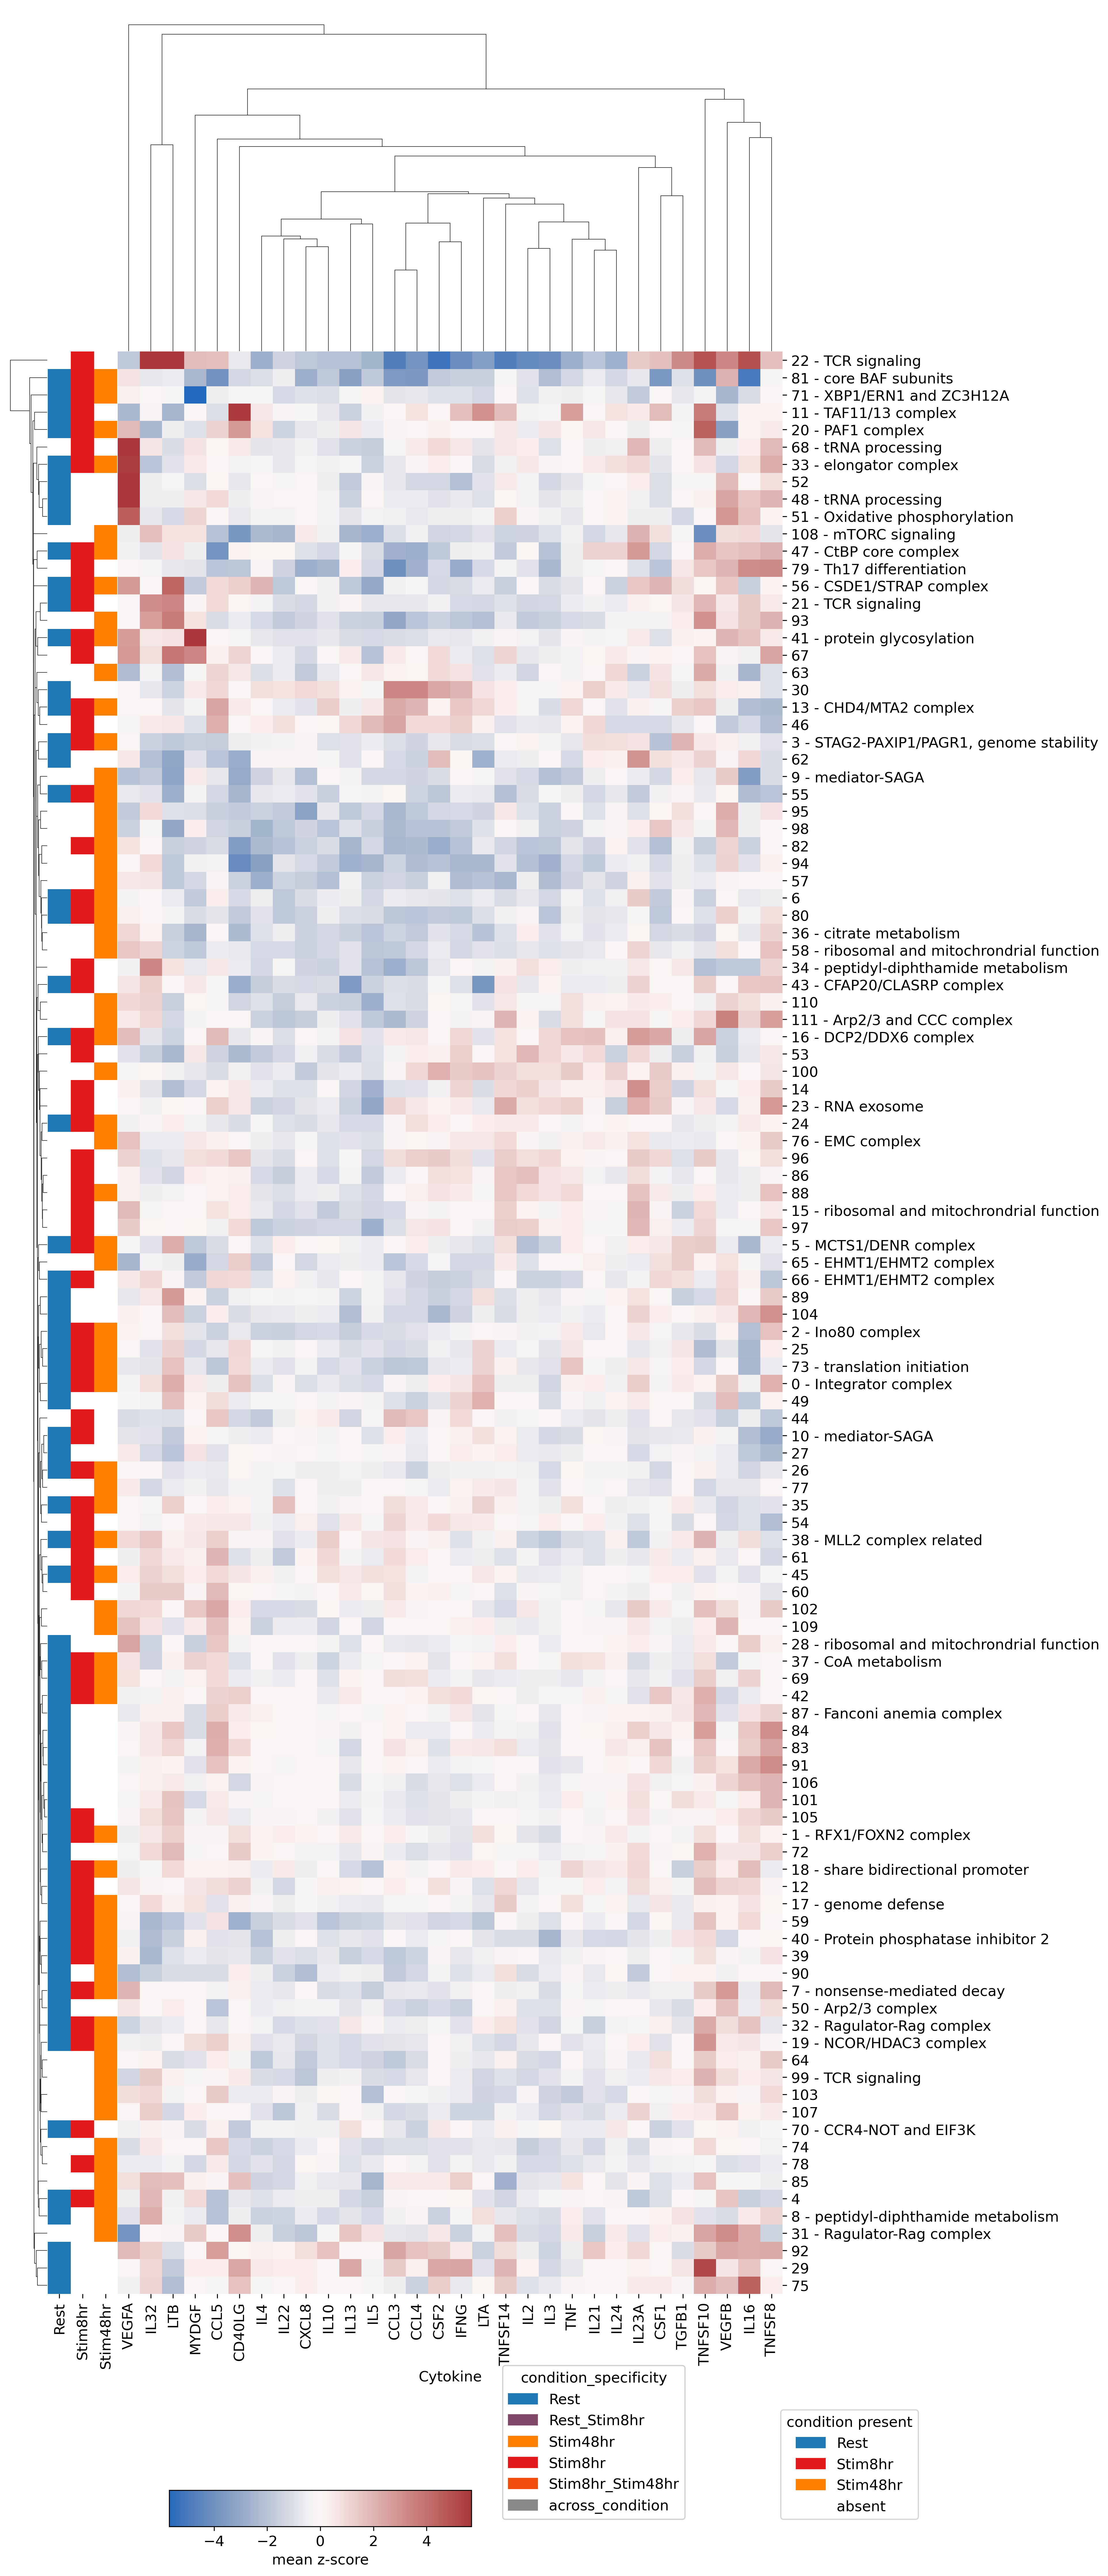

In [46]:
# Clustered heatmap of mean zscore per cluster on cytokines
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

cond_palette = palettes['culture_condition']  # {'Rest': ..., 'Stim8hr': ..., 'Stim48hr': ...}

# --- Row annotations ---
meta = cluster_cytokine_df[['manual_annotation', 'condition_specificity',
                             'has_Rest', 'has_Stim8hr', 'has_Stim48hr']].copy()

# condition_specificity: derive color by presence of each condition token
def spec_color(spec):
    conditions = ['Rest', 'Stim8hr', 'Stim48hr']
    present = [c for c in conditions if c in spec]
    if len(present) == 3 or spec == 'across_condition':
        return '#888888'
    if len(present) == 1:
        return cond_palette[present[0]]
    # two conditions: blend via average RGB
    import numpy as np
    from matplotlib.colors import to_rgb
    rgb = np.mean([to_rgb(cond_palette[c]) for c in present], axis=0)
    return rgb

spec_colors = meta['condition_specificity'].map(spec_color)

# Binary condition columns: condition color if 1, white if 0x
def binary_colors(col, condition):
    return col.map(lambda v: cond_palette[condition] if v == 1 else 'white')

row_colors = pd.DataFrame({
    'Rest':     binary_colors(meta['has_Rest'],     'Rest').values,
    'Stim8hr':  binary_colors(meta['has_Stim8hr'],  'Stim8hr').values,
    'Stim48hr': binary_colors(meta['has_Stim48hr'], 'Stim48hr').values,
}, index=meta.index)

# Row labels: integer cluster id + annotation (omit if 'unknown')
heatmap_data = cluster_cytokine_df[cytokines_present].copy()
def make_label(idx, annot):
    cluster_int = int(idx)
    if annot == 'unknown':
        return str(cluster_int)
    return f"{cluster_int} - {annot}"

row_labels = [make_label(idx, cluster_cytokine_df.loc[idx, 'manual_annotation'])
              for idx in heatmap_data.index]
heatmap_data.index = row_labels
row_colors.index = row_labels

# Color scale clipped at 98th percentile
vmax = heatmap_data.abs().quantile(0.98).max()

g = sns.clustermap(
    heatmap_data,
    row_colors=row_colors,
    cmap='vlag',
    center=0,
    vmin=-vmax,
    vmax=vmax,
    figsize=(14, max(8, len(heatmap_data) * 0.25)),
    xticklabels=True,
    yticklabels=True,
    dendrogram_ratio=(0.05, 0.15),  # (col/top dendrogram, row dendrogram)
    cbar_pos=None,          # suppress default colorbar; we'll add it manually
    linewidths=0,
)
g.ax_heatmap.set_xlabel('Cytokine', fontsize=12)
g.ax_heatmap.set_ylabel('')
g.ax_heatmap.tick_params(axis='x', labelsize=12, rotation=90)
g.ax_heatmap.tick_params(axis='y', labelsize=12)
g.ax_row_colors.tick_params(axis='x', labelsize=12)

# --- Add colorbar below the heatmap ---
cbar_ax = g.fig.add_axes([0.15, -0.05, 0.25, 0.015])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap='vlag', norm=plt.Normalize(vmin=-vmax, vmax=vmax))
sm.set_array([])
cb = g.fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label='mean z-score')
cb.ax.tick_params(labelsize=12)
cb.ax.set_xlabel('mean z-score', fontsize=12)

# --- Legends for row annotations ---
# condition_specificity legend
spec_vals = cluster_cytokine_df['condition_specificity'].unique()
spec_handles = [mpatches.Patch(color=spec_color(s), label=s) for s in sorted(spec_vals)]

# binary condition legend
bin_handles = [mpatches.Patch(color=cond_palette[c], label=c) for c in ['Rest', 'Stim8hr', 'Stim48hr']]
bin_handles += [mpatches.Patch(color='white', edgecolor='grey', label='absent')]

legend1 = g.fig.legend(handles=spec_handles, title='condition_specificity',
                        loc='lower left', bbox_to_anchor=(0.42, -0.05),
                        fontsize=12, title_fontsize=12, frameon=True)
g.fig.legend(handles=bin_handles, title='condition present',
             loc='lower left', bbox_to_anchor=(0.65, -0.05),
             fontsize=12, title_fontsize=12, frameon=True)
g.fig.add_artist(legend1)

plt.savefig('results/cluster_cytokine_effects_heatmap.pdf', bbox_inches='tight')
plt.show()